<a href="https://colab.research.google.com/github/noor7475/Breast-Cancer-Classifier/blob/main/breast_cancer_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import warnings
import logging
from pathlib import Path
import random

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score,
)
import joblib

# Configuration

In [ ]:
CFG = {
    "random_state":      42,
    "test_size":         0.20,
    "cv_folds":          5,
    "corr_threshold":    0.92,   # drop one of any two features correlated above this
    "cardinality_limit": 0.90,   # drop column if >90% of its values are unique
    "missing_col_limit": 0.50,   # drop column if >50% of train rows are missing
    "threshold":         0.30,   # decision threshold (recall-optimised for cancer)
    "model_path":        "best_model.joblib",
}

In [ ]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    handlers=[logging.StreamHandler()],
)
log = logging.getLogger(__name__)

# Data Ingestion

In [ ]:
def load_data(csv_path: str | None = None) -> pd.DataFrame:
    """Load from CSV or fall back to sklearn breast-cancer dataset."""
    if csv_path:
        if Path(csv_path).exists():
            df = pd.read_csv(csv_path)
            log.info("Loaded CSV: %s  shape=%s", csv_path, df.shape)
            return df
        log.warning("CSV not found: %s — falling back to built-in dataset.", csv_path)

    log.info("Using sklearn built-in breast-cancer dataset.")
    bc = load_breast_cancer(as_frame=True)
    df = bc.frame.rename(columns={"target": "diagnosis"})
    df["diagnosis"] = df["diagnosis"].map({1: 0, 0: 1})   # 1 = Malignant
    return df

# Basic Cleaning  

In [ ]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Minimal cleaning before the split:
      - Drop duplicate rows (essential for valid validation)
      - Encode target column (M/B -> 1/0)
    """
    log.info("── Cleaning ─────────────────────────────────────")

    # 1. Drop duplicate rows
    dupes = df.duplicated().sum()
    if dupes:
        df = df.drop_duplicates()
        log.info("Removed %d duplicate rows.", dupes)
    else:
        log.info("No duplicate rows.")

    # 2. Encode target if still text
    if "diagnosis" in df.columns:
        if df["diagnosis"].dtype == object:
            df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
            log.info("Target encoded: M→1, B→0.")
        elif df["diagnosis"].min() == 1 and df["diagnosis"].max() == 2:
            # Handle cases where it might be 1 and 2 instead of 0 and 1
            df["diagnosis"] = df["diagnosis"].map({1: 0, 2: 1})

    log.info("Shape after basic cleaning: %s", df.shape)
    return df

# EDA

In [ ]:
def eda_plots(df: pd.DataFrame):
    log.info("── EDA plots ────────────────────────────────────")

    # Class balance
    fig, ax = plt.subplots(figsize=(5, 4))
    counts = df["diagnosis"].value_counts()
    ax.bar(["Benign (0)", "Malignant (1)"], counts.values,
           color=["steelblue", "tomato"], edgecolor="white")
    ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
    fig.tight_layout()
    plt.show()

    print("\n")

    # Correlation heatmap (lower triangle only)
    fig, ax = plt.subplots(figsize=(20, 12))
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True,
                cmap="coolwarm", linewidths=1, fmt='.2f', ax=ax)
    ax.set_title("Feature Correlation Heatmap", fontsize=20, fontweight="bold")
    fig.tight_layout()
    plt.show()

# Train / Test Split

In [ ]:
def split_data(df: pd.DataFrame):
    X = df.drop("diagnosis", axis=1)
    y = df["diagnosis"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=CFG["test_size"],
        random_state=CFG["random_state"],
        stratify=y,
    )
    log.info("Train=%d  Test=%d  Malignant-rate=%.1f%%",
             len(X_train), len(X_test), 100 * y.mean())
    return X_train, X_test, y_train, y_test

# Model definitions  +  Hyperparameter Grids

In [ ]:
def get_model_configs(feature_list: list) -> dict:
    numeric_transformer = Pipeline(steps=[
        ('imputer', IterativeImputer(max_iter=10, random_state=CFG["random_state"])),
        ('scaler',  StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, feature_list)
        ],
        remainder='drop'
    )

    base_steps = [
        ("pre", preprocessor),
        ("selector", SelectKBest(f_classif, k="all")),
    ]

    return {
        "SVM": {
            "pipeline": Pipeline(base_steps + [
                ("model", SVC(probability=True, random_state=CFG["random_state"]))
            ]),
            "param_grid": {
                "selector__k":   [10, 15, "all"],
                "model__C":      [0.1, 1, 10, 15, 20],
                "model__gamma":  [0.0001, 0.001, 0.01, 0.1],
                "model__kernel": ["rbf", "linear"],
            },
        },
        "RandomForest": {
            "pipeline": Pipeline(base_steps + [
                ("model", RandomForestClassifier(random_state=CFG["random_state"]))
            ]),
            "param_grid": {
                "selector__k":              [10, 15, "all"],
                "model__n_estimators":      [100, 200],
                "model__max_depth":         [None, 5, 10],
                "model__min_samples_split": [2, 5],
            },
        },
        "GradientBoosting": {
            "pipeline": Pipeline(base_steps + [
                ("model", GradientBoostingClassifier(random_state=CFG["random_state"]))
            ]),
            "param_grid": {
                "selector__k":         [10, 15, "all"],
                "model__n_estimators": [100, 200],
                "model__learning_rate":[0.05, 0.1, 0.2],
                "model__max_depth":    [3, 5],
            },
        },
        "LogisticRegression": {
            "pipeline": Pipeline(base_steps + [
                ("model", LogisticRegression(
                    random_state=CFG["random_state"], max_iter=1000))
            ]),
            "param_grid": {
                "selector__k":   [10, 15, "all"],
                "model__C":      [0.01, 0.1, 1, 10],
                "model__solver": ["lbfgs", "saga"],
            },
        },
    }


# Training and Hyperparameter Tuning

In [ ]:
def train_models(X_train, y_train, configs: dict) -> dict:
    log.info("── Training ─────────────────────────────────────")
    cv      = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True,
                              random_state=CFG["random_state"])
    results = {}

    for name, cfg in configs.items():
        log.info("Training %s …", name)
        t0 = time.time()

        gs = GridSearchCV(
            cfg["pipeline"],
            cfg["param_grid"],
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        gs.fit(X_train, y_train)
        elapsed = time.time() - t0

        log.info("  Best CV AUC=%.4f  params=%s  time=%.1fs",
                 gs.best_score_, gs.best_params_, elapsed)

        results[name] = {
            "best_estimator": gs.best_estimator_,
            "best_params":    gs.best_params_,
            "cv_auc":         gs.best_score_,
            "train_time":     elapsed,
        }

    return results

# Evaluation

In [ ]:
def evaluate_models(results: dict, X_train, X_test,
                    y_train, y_test) -> pd.DataFrame:
    log.info("── Evaluation ───────────────────────────────────")
    rows = []

    for name, res in results.items():
        est       = res["best_estimator"]
        t_pred    = est.predict(X_train)
        p_pred    = est.predict(X_test)
        p_prob    = est.predict_proba(X_test)[:, 1]
        p_pred_t  = (p_prob >= CFG["threshold"]).astype(int)

        t_acc   = accuracy_score(y_train, t_pred)
        p_acc   = accuracy_score(y_test,  p_pred)
        p_acc_t = accuracy_score(y_test,  p_pred_t)
        auc     = roc_auc_score(y_test, p_prob)
        ap      = average_precision_score(y_test, p_prob)
        gap     = t_acc - p_acc

        log.info("  %s  train=%.4f  test=%.4f  gap=%.4f  AUC=%.4f",
                 name, t_acc, p_acc, gap, auc)

        results[name].update({
            "train_acc":    t_acc,
            "test_acc":     p_acc,
            "test_acc_t":   p_acc_t,
            "auc":          auc,
            "ap":           ap,
            "gap":          gap,
            "test_preds":   p_pred,
            "test_preds_t": p_pred_t,
            "test_probs":   p_prob,
        })

        rows.append({
            "Model":          name,
            "Train Acc":      f"{t_acc:.4f}",
            "Test Acc":       f"{p_acc:.4f}",
            "Test Acc (thr)": f"{p_acc_t:.4f}",
            "AUC-ROC":        f"{auc:.4f}",
            "Avg Precision":  f"{ap:.4f}",
            "Overfit Gap":    f"{gap:.4f}",
            "CV AUC":         f"{res['cv_auc']:.4f}",
            "Train Time (s)": f"{res['train_time']:.1f}",
        })

    summary = pd.DataFrame(rows)

    print("\n" + "="*80)
    print("                FINAL MODEL PERFORMANCE COMPARISON")
    print("="*80)
    print(summary.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))
    print("="*80 + "\n")

    return summary

# Visualization

In [ ]:
def plot_results(results: dict, y_test):
    log.info("── Plotting ─────────────────────────────────────")
    palette = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

    # ROC curves
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    for (name, res), col in zip(results.items(), palette):
        fpr, tpr, _ = roc_curve(y_test, res["test_probs"])
        ax.plot(fpr, tpr, lw=2, color=col,
                label=f"{name}  AUC={res['auc']:.3f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    fig.tight_layout()
    plt.show()

    # Precision-Recall curves
    fig, ax = plt.subplots(figsize=(7, 6))
    for (name, res), col in zip(results.items(), palette):
        prec, rec, _ = precision_recall_curve(y_test, res["test_probs"])
        ax.plot(rec, prec, lw=2, color=col,
                label=f"{name}  AP={res['ap']:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curves", fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    fig.tight_layout()
    plt.show()

    # Confusion matrices
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
    if len(results) == 1:
        axes = [axes]
    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, res["test_preds_t"])
        ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"]).plot(
            ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"{name}\n(thr={CFG['threshold']})",
                     fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()

    # Model comparison bar chart
    names = list(results.keys())
    aucs  = [results[n]["auc"]      for n in names]
    accs  = [results[n]["test_acc"] for n in names]
    x = np.arange(len(names))
    w = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w/2, aucs, w, label="AUC-ROC", color=palette[:len(names)])
    ax.bar(x + w/2, accs, w, label="Test Acc", color=palette[:len(names)], alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylim(0.85, 1.02)
    ax.set_ylabel("Score")
    ax.set_title("Model Comparison", fontsize=13, fontweight="bold")
    ax.legend()
    for xi, (a, b) in zip(x, zip(aucs, accs)):
        ax.text(xi - w/2, a + 0.002, f"{a:.3f}", ha="center", fontsize=8)
        ax.text(xi + w/2, b + 0.002, f"{b:.3f}", ha="center", fontsize=8)
    fig.tight_layout()
    plt.show()

# Select Best Model & Save

In [ ]:
def select_and_save(results: dict, y_test) -> str:
    log.info("── Model Selection ──────────────────────────────")

    best_name = max(results, key=lambda n: results[n]["auc"])
    best      = results[best_name]
    log.info("Best model: %s  (AUC=%.4f)", best_name, best["auc"])

    # Print classification report
    print(f"\nClassification report — {best_name}  "
          f"(threshold = {CFG['threshold']})\n")
    print(classification_report(
        y_test, best["test_preds_t"],
        target_names=["Benign", "Malignant"],
    ))

    # Save only the best pipeline
    joblib.dump(best["best_estimator"], CFG["model_path"])
    log.info("Best pipeline saved → %s", CFG["model_path"])

    return CFG["model_path"]

# Orchestrator

In [ ]:
def run_pipeline(csv_path: str | None = None):
    log.info("╔═════════════════════════════════════════╗")
    log.info("║     BREAST CANCER ML PIPELINE START     ║")
    log.info("╚═════════════════════════════════════════╝")
    t_start = time.time()

    # Load and Basic Clean (Duplicates/Encoding)
    df = load_data(csv_path)
    df = clean_data(df)
    eda_plots(df)

    # Split Data
    X_train, X_test, y_train, y_test = split_data(df)

    log.info("── Identifying Feature Guest List ───────────────")
    # Identify columns that are mostly empty in training
    missing_pct = X_train.isnull().mean()
    cols_to_keep = missing_pct[missing_pct <= CFG["missing_col_limit"]].index.tolist()

    # Identify highly correlated features
    temp_df = X_train[cols_to_keep].dropna()
    corr_matrix = temp_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [c for c in upper.columns if any(upper[c] > CFG["corr_threshold"])]

    # FINAL GUEST LIST: Survived both missingness and correlation checks
    final_features = [c for c in cols_to_keep if c not in to_drop_corr]
    log.info("Final feature count for Pipeline: %d", len(final_features))

    # Define and Train
    configs = get_model_configs(final_features)
    results = train_models(X_train, y_train, configs)

    # Evaluate
    summary = evaluate_models(results, X_train, X_test, y_train, y_test)
    plot_results(results, y_test)

    # Save
    model_path = select_and_save(results, y_test)

    elapsed = time.time() - t_start
    log.info("Pipeline complete in %.1fs — model saved to: %s",
             elapsed, model_path)

    return {"summary": summary, "results": results, "model_path": model_path}

2026-03-28 03:20:42,043  INFO     ╔═════════════════════════════════════════╗
2026-03-28 03:20:42,044  INFO     ║     BREAST CANCER ML PIPELINE START     ║
2026-03-28 03:20:42,046  INFO     ╚═════════════════════════════════════════╝
2026-03-28 03:20:42,077  INFO     Loaded CSV: /content/drive/MyDrive/Level 1/breast-cancer [SVM and Hyper Parm Tuning.csv  shape=(569, 32)
2026-03-28 03:20:42,077  INFO     ── Cleaning ─────────────────────────────────────
2026-03-28 03:20:42,090  INFO     No duplicate rows.
2026-03-28 03:20:42,093  INFO     Target encoded: M→1, B→0.
2026-03-28 03:20:42,094  INFO     Shape after basic cleaning: (569, 32)
2026-03-28 03:20:42,095  INFO     ── EDA plots ────────────────────────────────────


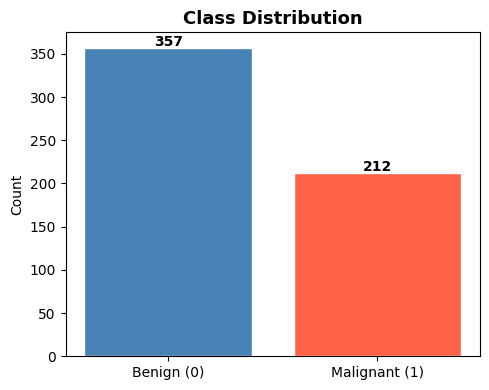

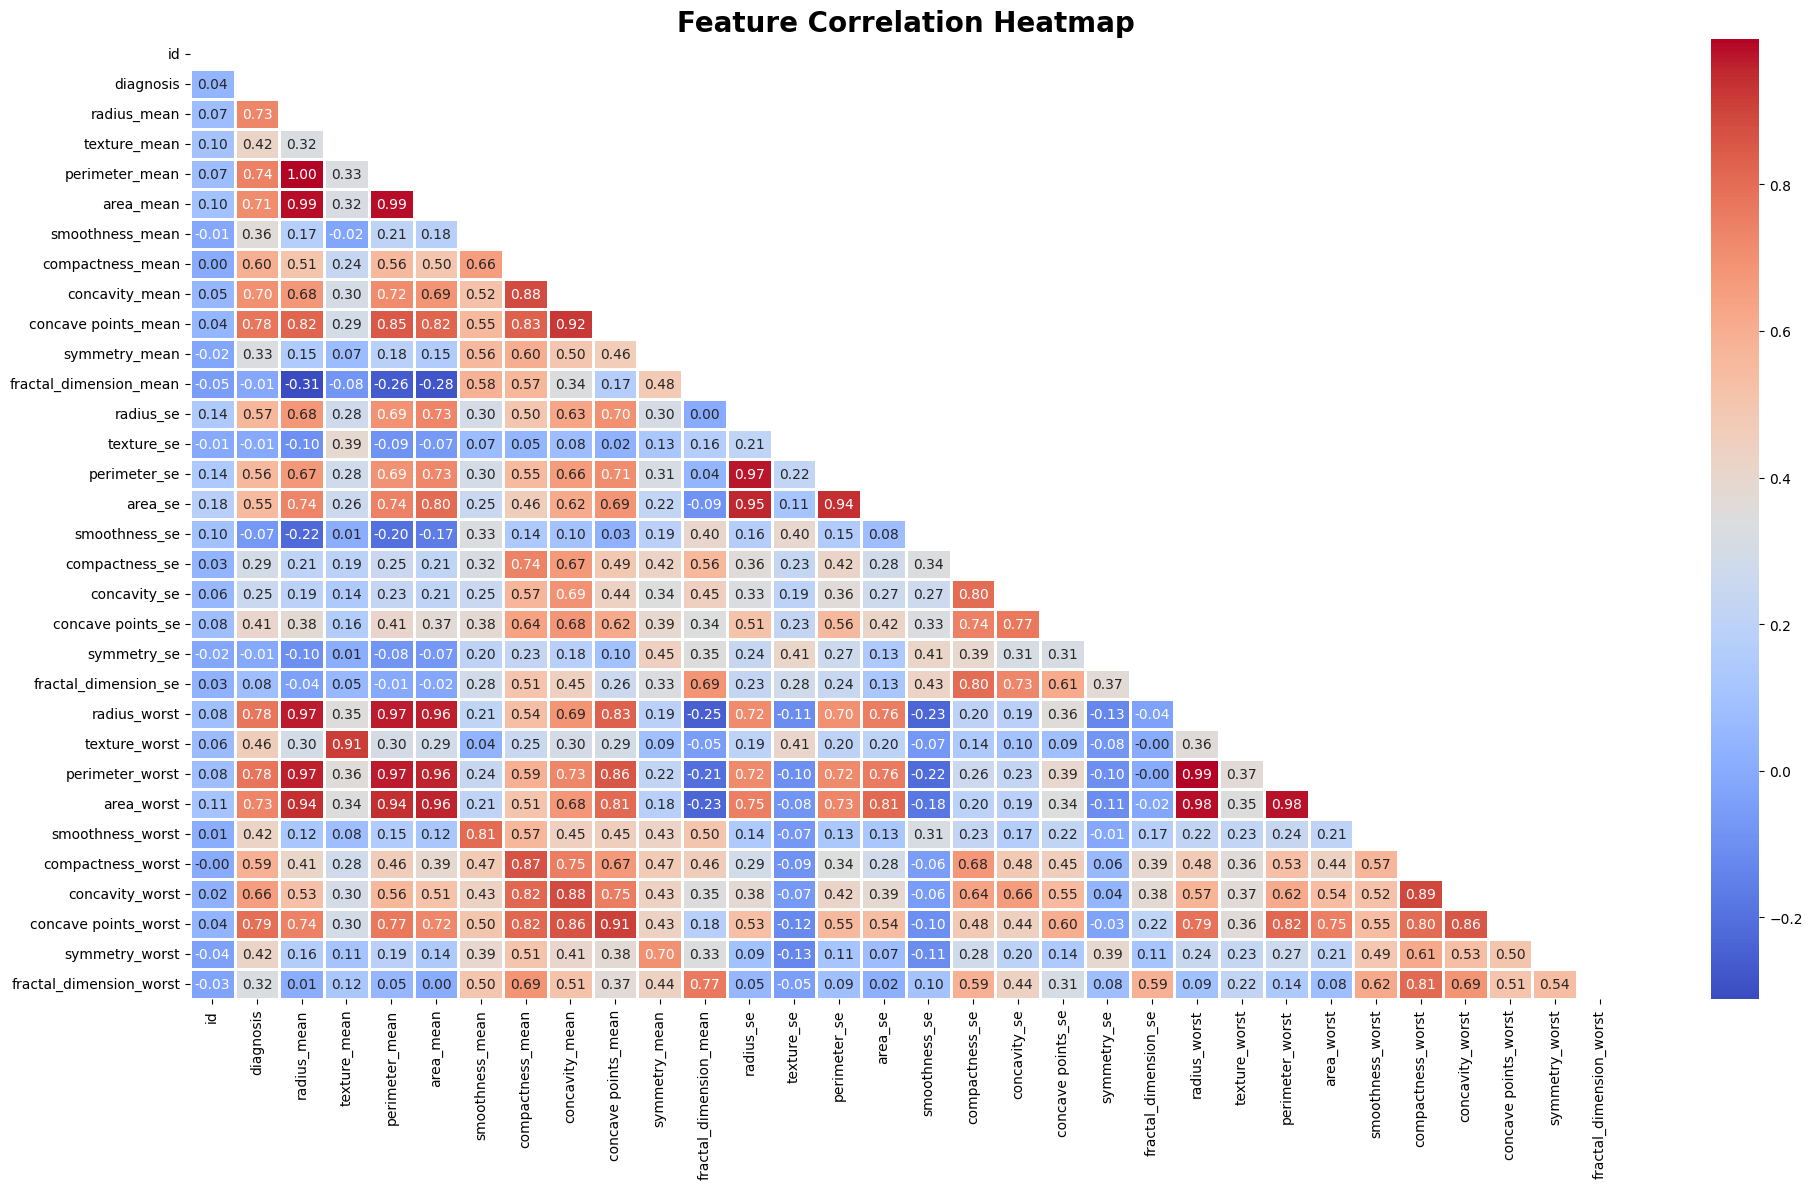

2026-03-28 03:20:43,453  INFO     Train=455  Test=114  Malignant-rate=37.3%
2026-03-28 03:20:43,454  INFO     ── Identifying Feature Guest List ───────────────
2026-03-28 03:20:43,466  INFO     Final feature count for Pipeline: 23
2026-03-28 03:20:43,467  INFO     ── Training ─────────────────────────────────────
2026-03-28 03:20:43,468  INFO     Training SVM …
2026-03-28 03:21:18,552  INFO       Best CV AUC=0.9958  params={'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf', 'selector__k': 'all'}  time=35.1s
2026-03-28 03:21:18,555  INFO     Training RandomForest …
2026-03-28 03:22:01,279  INFO       Best CV AUC=0.9911  params={'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'selector__k': 'all'}  time=42.7s
2026-03-28 03:22:01,280  INFO     Training GradientBoosting …
2026-03-28 03:23:15,559  INFO       Best CV AUC=0.9935  params={'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 200, 'selector__k': 15}  time=74.3


                FINAL MODEL PERFORMANCE COMPARISON
             Model Train Acc Test Acc Test Acc (thr) AUC-ROC Avg Precision Overfit Gap CV AUC Train Time (s)
               SVM    0.9846   0.9737         0.9737  0.9957        0.9941      0.0109 0.9958           35.1
      RandomForest    1.0000   0.9474         0.9649  0.9949        0.9912      0.0526 0.9911           42.7
  GradientBoosting    1.0000   0.9474         0.9474  0.9917        0.9879      0.0526 0.9935           74.3
LogisticRegression    0.9780   0.9825         0.9737  0.9954        0.9938     -0.0044 0.9950            6.6



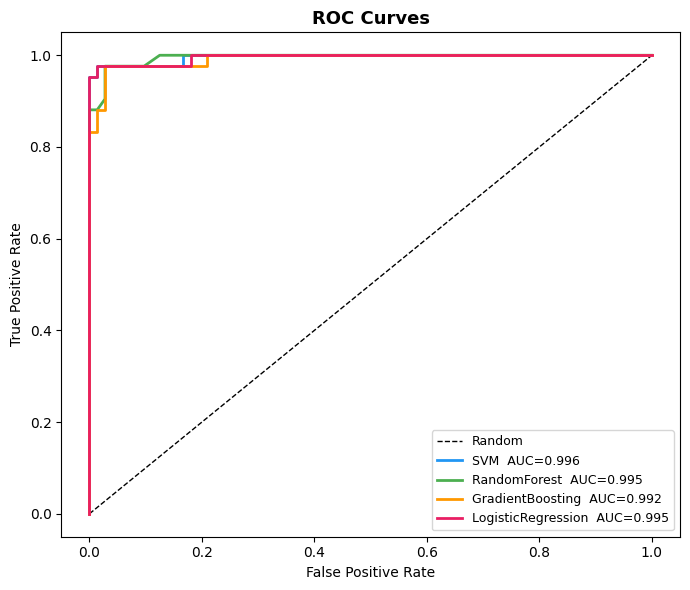

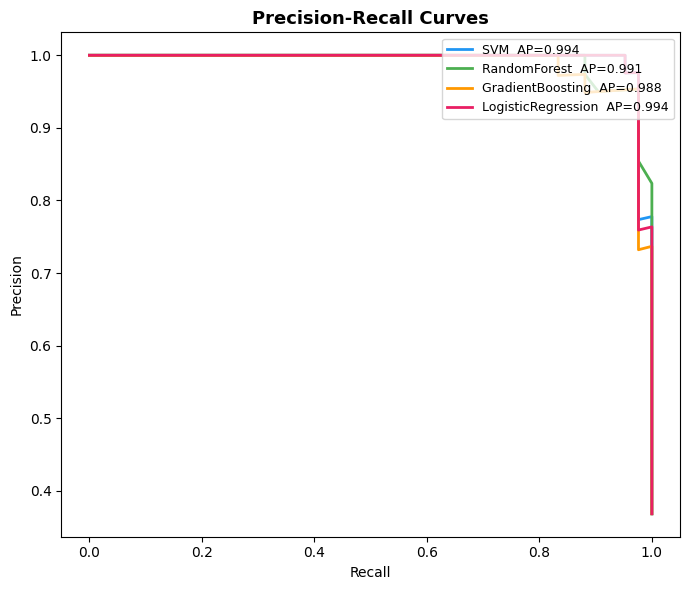

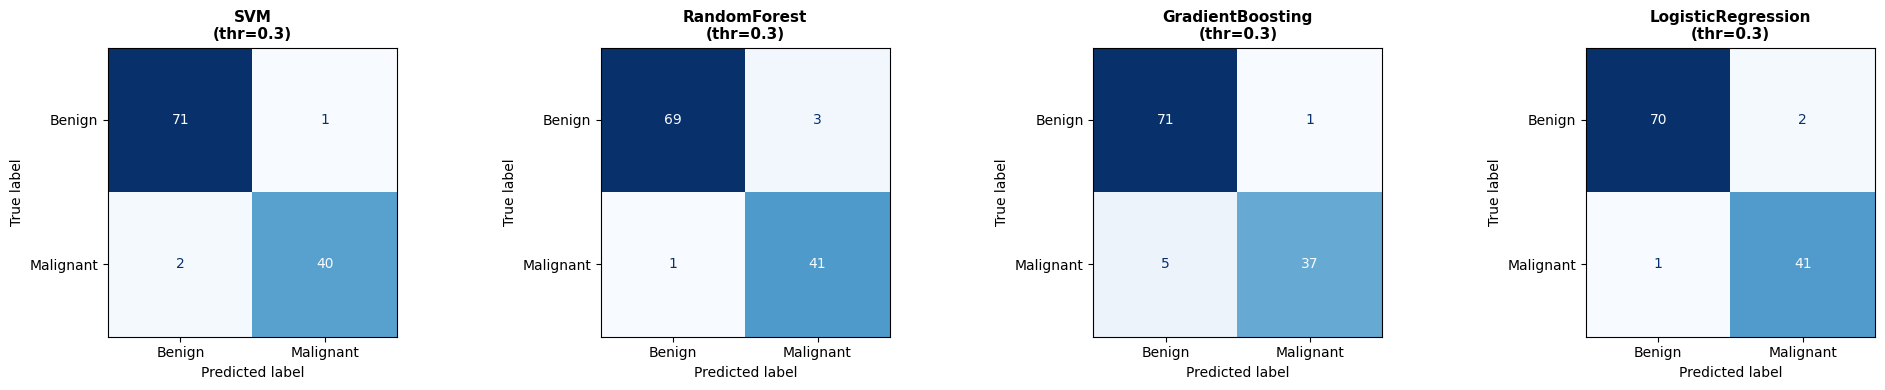

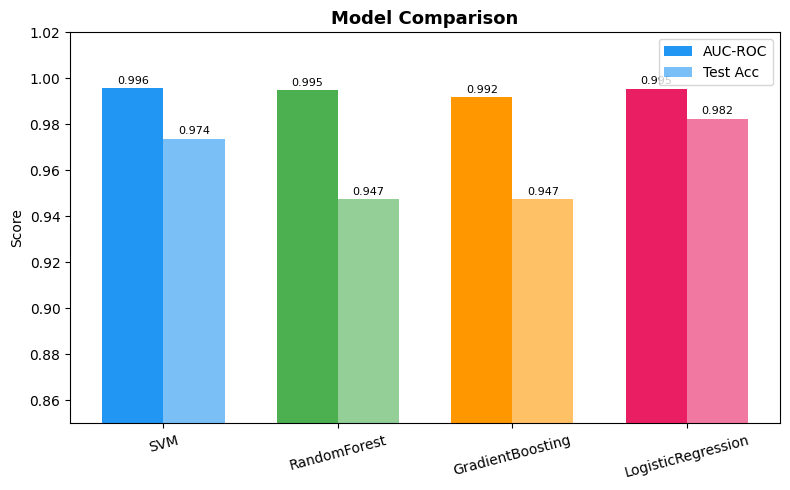

2026-03-28 03:23:22,938  INFO     ── Model Selection ──────────────────────────────
2026-03-28 03:23:22,939  INFO     Best model: SVM  (AUC=0.9957)
2026-03-28 03:23:22,973  INFO     Best pipeline saved → /content/drive/MyDrive/breast_cancer_model/best_model.joblib
2026-03-28 03:23:22,975  INFO     Pipeline complete in 160.9s — model saved to: /content/drive/MyDrive/breast_cancer_model/best_model.joblib



Classification report — SVM  (threshold = 0.3)

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
# Reset handlers to ensure they point to the current Colab cell
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s %(message)s',
    handlers=[logging.StreamHandler()] # This sends logs to the screen
)
log = logging.getLogger(__name__)

csv_path = "breast-cancer.csv"
_ = run_pipeline(csv_path)

# Inference

In [ ]:
# read and clean dataset
df = pd.read_csv("breast-cancer.csv")
df = clean_data(df)

In [ ]:
def predict(model_path: str, new_data: pd.DataFrame,
            threshold: float | None = None) -> pd.DataFrame:
    """
    Load the saved pipeline and predict on new patient data.
    The pipeline automatically applies scaling and feature selection —
    you only need to pass the raw feature values.
    """
    thr           = threshold or CFG["threshold"]
    est           = joblib.load(model_path)
    probabilities = est.predict_proba(new_data)[:, 1]
    predictions   = (probabilities >= thr).astype(int)

    return pd.DataFrame({
        "probability": probabilities,
        "prediction":  predictions,
        "label":       ["Malignant" if p else "Benign" for p in predictions],
    })

In [ ]:
def get_random_samples(data: pd.DataFrame, n: int = 5):
    """
    Extracts random patients
    """
    samples = data.sample(n=n, random_state=None).copy()

    truth_labels = []
    if 'diagnosis' in samples.columns:
        actual_values = samples['diagnosis'].tolist()
        truth_labels = ["Malignant" if v == 1 else "Benign" for v in actual_values]
        samples = samples.drop(columns=['diagnosis'])

    print(f"Extracted {n} random samples")
    return samples, truth_labels

In [ ]:
model_path = "best_model.joblib"

In [ ]:
# Get 5 samples
test_data, truths = get_random_samples(df, n=5)

# Predict
results = predict(
    model_path=model_path,
    new_data=test_data
)

# Add truths for a side-by-side view
results['actual_truth'] = truths
print(results)

Extracted 5 random samples
   probability  prediction      label actual_truth
0     0.000168           0     Benign       Benign
1     1.000000           1  Malignant    Malignant
2     0.011687           0     Benign       Benign
3     0.000470           0     Benign       Benign
4     0.027655           0     Benign    Malignant


In [ ]:
# Get 5 samples
test_data, truths = get_random_samples(df, n=5)

# Predict
results = predict(
    model_path=model_path,
    new_data=test_data
)

# Add truths for a side-by-side view
results['actual_truth'] = truths
print(results)

Extracted 5 random samples
   probability  prediction   label actual_truth
0     0.056949           0  Benign       Benign
1     0.000101           0  Benign       Benign
2     0.001766           0  Benign       Benign
3     0.020430           0  Benign       Benign
4     0.000411           0  Benign       Benign


In [ ]:
# Get 5 samples
test_data, truths = get_random_samples(df, n=5)

# Predict
results = predict(
    model_path=model_path,
    new_data=test_data
)

# Add truths for a side-by-side view
results['actual_truth'] = truths
print(results)

Extracted 5 random samples
   probability  prediction      label actual_truth
0     0.999999           1  Malignant    Malignant
1     0.001141           0     Benign       Benign
2     0.999983           1  Malignant    Malignant
3     0.006454           0     Benign       Benign
4     0.000664           0     Benign       Benign
